# Chuẩn bị

**Cài đặt các Thư viện sử dụng**

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, confusion_matrix

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

from gensim.models import Word2Vec

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
import warnings
warnings.filterwarnings("ignore")

**Cài đặt dataFrame**

In [6]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

**Đọc dữ liệu**

In [7]:

file = os.path.join("../../Data_Train", "Vietnamese.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

file_stopword = os.path.join("../../Data_Train", "vietnamese-stopwords-dash.txt")
with open(file_stopword, 'r', encoding='utf-8') as file:
    stopwords = file.read().split('\n')

# Khám phá dữ liệu

**Xem thông tin dữ liệu**

In [8]:
data_df.head(5)

,title,text,label
0,Cấm biển di dân khỏi vùng nguy hiểm từ Quảng N...,Các tỉnh ven biển phía Bắc cấp tập di dân tạm ...,0
1,Hội Cựu Công an nhân dân là thành viên Mặt trậ...,Ủy ban Trung ương Mặt trận Tổ quốc (MTTQ) Việt...,0
2,Thêm 30 cá thể hổ và sư tử ở Vườn thú Mỹ Quỳnh...,Ngày 2-10 bà Đinh Thị Phương Khanh Phó Giám đố...,0
3,Đà Lạt: Lũ cuốn trôi ô tô 1 người mất tích,Khoảng 13 giờ 30 phút ngày 2-10 tại đập tràn t...,0
4,Kiên Giang: Cất bốc 19 hài cốt liệt sĩ tại huy...,Ngày 2-10 thông tin từ Bộ Chỉ huy quân sự tỉnh...,0


**Xáo trộn dữ liệu**

In [9]:
data_df=data_df.sample(frac=1, random_state=42).reset_index(drop=True)

In [10]:
data_df.head(5)

,title,text,label
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1
1,Biển Đông: Trung Quốc âm mưu chia rẽ Việt Nam ...,Nguồn hình ảnh BBC/Virma Simonette Philippines...,1
2,Mất căn cước công dân ở nước ngoài tôi có được...,Tôi đã từng làm căn cước công dân (CCCD). Cách...,0
3,Đường dây dùng trẻ em phục vụ khiêu dâm bị phá...,Đồng NaiCác nghi phạm mua bán sử dụng người dư...,0
4,Phạm Minh Hoàng: Hội Thánh Truyền Giáo Phục Hư...,Tình hình dịch Covid-19 tại Việt Nam đang rất ...,1


**Mô tả của dữ liệu**

In [11]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12600 entries, 0 to 12599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   12600 non-null  object
 1   text    12600 non-null  object
 2   label   12600 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 295.4+ KB


In [12]:
data_df.describe().round(1)

,label
count,12600.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.0
75%,1.0
max,1.0


**Kích thước của DataFrame và danh sách các tên cột**

In [13]:
features = data_df.columns.to_list()[:]
print(data_df.shape)
print(features)

(12600, 3)
['title', 'text', 'label']


**ý nghĩa các cột**
- title: Tên của tin tức
- text: nội dung của tin tức
- label: nhãn phân biệt tin giả hay tin thật

**Xem số hàng và cột của dữ liệu**

In [14]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

12600
3


**Kiểm tra dữ liệu có bị lặp**

In [15]:
dup=data_df.index.duplicated().sum()
dup

0

**Kiểm tra dữ liệu có bị thiếu**

In [16]:
data_df['title'].isnull().sum()

0

In [17]:
data_df['text'].isnull().sum()

0

In [18]:
data_df['label'].isnull().sum()

0

**Kiểm tra loại dữ liệu**

In [19]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [20]:
open_object_dtype(data_df['title'])

{str}

In [21]:
open_object_dtype(data_df['text'])

{str}

In [22]:
open_object_dtype(data_df['label'])

{int}

**Kiểm tra số từ của title và text**

In [23]:
data_df["title_length"] = data_df["title"].apply(lambda title: len(title.split(" ")))
data_df["text_length"] = data_df["text"].apply(lambda text: len(text.split(" ")))

In [24]:
data_df[["title_length", "text_length"]].describe()

,title_length,text_length
count,12600.000000,12600.000000
mean,13.281905,913.570556
std,4.446797,828.093960
min,1.000000,52.000000
25%,10.000000,384.000000
50%,14.000000,699.000000
75%,16.000000,1174.000000
max,47.000000,15495.000000


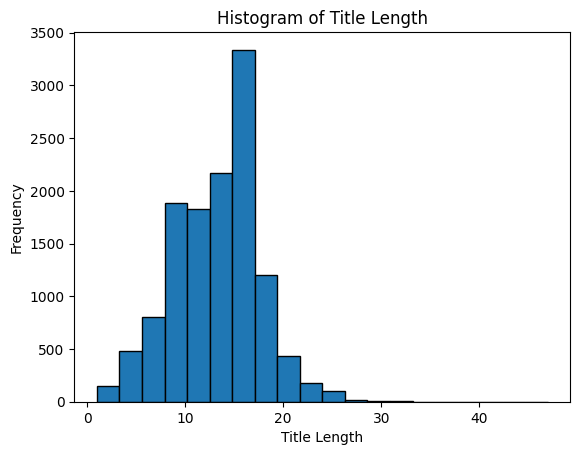

In [25]:
data_df["title_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Title Length')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.show()

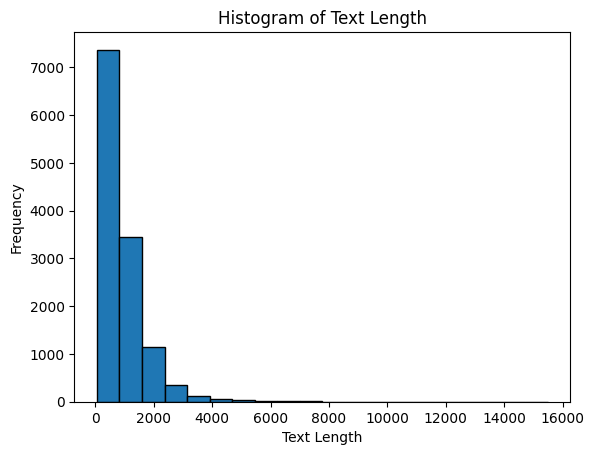

In [26]:
data_df["text_length"].plot(kind="hist", bins=20, edgecolor='black')
plt.title('Histogram of Text Length')
plt.xlabel('Text Length')
plt.ylabel('Frequency')
plt.show()

**Xem phân bố dữ liệu**

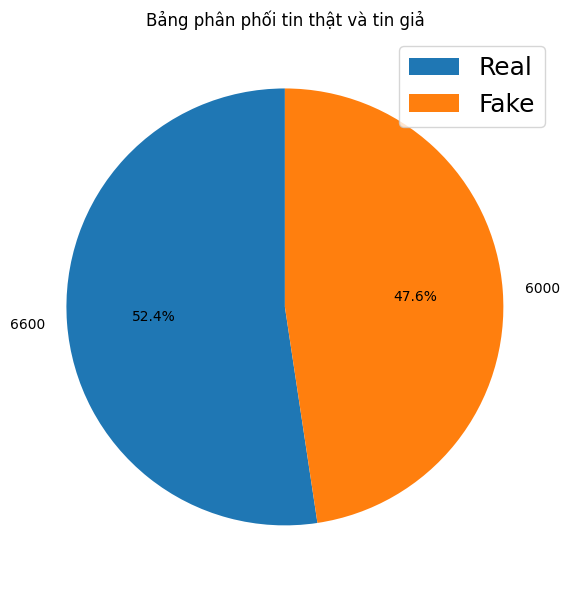

In [27]:
# data quantity chart
def quantity_chart():
    counts_df1 = data_df['label'].value_counts()

    plt.figure(figsize=(6, 6))

    plt.pie(counts_df1, labels=counts_df1, autopct='%1.1f%%', startangle=90)
    plt.title('Bảng phân phối tin thật và tin giả')

    labels = ['Real' if label == 0 else 'Fake' for label in counts_df1.index]
    plt.legend(labels=labels, loc="best", fontsize=18)  # Tăng kích thước nhãn trong chú thích
    plt.tight_layout()
    plt.show()
quantity_chart()

**Chiều dài trung bình tiêu đề của 1 tin tức**

In [28]:
len_title_sum=0

for i in data_df['title']:
    len_word=i.split()
    len_title_sum += len(len_word)

avg_title=len_title_sum/data_df['title'].count()

avg_title

13.282619047619047

**Độ dài lớn nhất của tiêu đề**

In [29]:
max_title_len=0
for i in data_df['title']:
    len_word = i.split()
    if len(len_word) > max_title_len:
        max_title_len = len(len_word)
max_title_len

47

**Độ dài nhỏ nhất của tiêu đề**

In [30]:
min_title_len=max_title_len
for i in data_df['title']:
    len_word=i.split()
    if len(len_word) < min_title_len:
        min_title_len = len(len_word)

min_title_len

1

**Chiều dài trung bình text của 1 tin tức**

In [31]:
len_text_sum=0

for i in data_df['text']:
    len_word=i.split()
    len_text_sum += len(len_word)

avg_text=len_text_sum/data_df['text'].count()

avg_text

913.5705555555555

**Độ dài lớn nhất của text**

In [32]:
max_text_len=0

for i in data_df['text']:
    len_word=i.split()
    if len(len_word)>max_text_len:
        max_text_len=len(len_word)

max_text_len

15495

**Độ dài nhỏ nhất của text**

In [33]:
min_text_len = max_text_len

for i in data_df['text']:
    len_word=i.split()
    if len(len_word) < min_text_len:
        min_text_len = len(len_word)

min_text_len

52

**Tổng số từ trong title**

In [34]:
total_words = data_df['title'].str.split().map(len).sum()
total_words

167361

**Tổng số từ trong text**

In [35]:
total_words = data_df['text'].str.split().map(len).sum()
total_words

11510989

**Số từ khác biệt trong title**

In [36]:
unique_words = len(set(' '.join(data_df['title']).split()))
unique_words

11752

**Số từ khác biệt trong text**

In [37]:
unique_words = len(set(' '.join(data_df['text']).split()))
unique_words

115253

**Số từ khác biệt trong title và text**

In [38]:
combined_text = ' '.join(data_df['title']) + ' ' + ' '.join(data_df['text'])
unique_words_combined = len(set(combined_text.split()))
unique_words_combined

117203

# Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

**Thư viện để xử lý**

In [39]:
from pyvi import ViTokenizer

In [40]:
def wordopt(text):
    text = text.lower()
    text = re.sub('[%s]' % re.escape("""!’‘–"#$%&'()*+,،-./:;<=>؟?@[\]^`{|}~“”…؛"""), ' ', text)
    text = re.sub('https?://\S+|www\.\S+|https?:\/\/.*[\r\n]*', ' ', text)
    text = re.sub('<.*?>+', ' ', text)
    # text = re.sub('\[.*?\]', ' ', text)
    text = re.sub('\\W', ' ', text)
    # text = re.sub('\w*\d\w*', ' ', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\s+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = text.strip()

    # update_text = ""
    # for word in text.split():
    #     if word not in stopwords:
    #         update_text += word + " "
        
    return text

In [41]:
# Compound Vietnamese word
def tokenizerVN(text):
    return ViTokenizer.tokenize(text)

**Hợp nhất title và text**

In [42]:
data_df['article'] = data_df["title"] +' '+  data_df["text"] 

In [43]:
data_df.head(1)

,title,text,label,title_length,text_length,article
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...


**Áp dụng các xử lý dữ liệu**

In [45]:
data_df['Compound_Content'] = data_df['article'].apply(wordopt)

In [46]:
data_df['Compound_Content_SW'] = data_df['Compound_Content'].apply(tokenizerVN)

In [47]:
data_df.head(1)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
0,Lưỡi gỗ Nguyễn Viết Thông,Hội đồng lý luận trung ương của đảng CSVN là n...,1,5,954,Lưỡi gỗ Nguyễn Viết Thông Hội đồng lý luận tru...,lưỡi gỗ nguyễn viết thông hội đồng lý luận tru...,lưỡi gỗ nguyễn viết thông hội_đồng lý_luận tru...


**Tổng số từ**

In [48]:
total_words = data_df['Compound_Content_SW'].str.split().map(len).sum()
total_words

8814661

**Số từ khác biệt còn lại**

In [49]:
unique_words_combined = len(set(' '.join(data_df['Compound_Content_SW']).split()))
unique_words_combined

67029

In [50]:
data_df.sample(10)

,title,text,label,title_length,text_length,article,Compound_Content,Compound_Content_SW
6060,Vỏ bọc giúp kẻ sát nhân đánh lừa FBI,MỹBa phụ nữ lần lượt biến mất bí ẩn khiến gia ...,0,9,2247,Vỏ bọc giúp kẻ sát nhân đánh lừa FBI MỹBa phụ ...,vỏ bọc giúp kẻ sát nhân đánh lừa fbi mỹba phụ ...,vỏ bọc giúp kẻ sát_nhân đánh_lừa fbi mỹba phụ_...
7275,Giám sát việc thực hiện chính sách đối với cán...,Chủ tịch Hội đồng Dân tộc Y Thanh Hà Niê Kđăm ...,0,16,1724,Giám sát việc thực hiện chính sách đối với cán...,giám sát việc thực hiện chính sách đối với cán...,giám_sát việc thực_hiện chính_sách đối_với cán...
10997,VÌ SAO CHÍNH THỂ VIỆT NAM HỚN HỞ TÔN TRỌNG TỰ ...,Nguồn cơn của động thái Mỹ điều hàng không mẫu...,1,22,712,VÌ SAO CHÍNH THỂ VIỆT NAM HỚN HỞ TÔN TRỌNG TỰ ...,vì sao chính thể việt nam hớn hở tôn trọng tự ...,vì_sao chính_thể việt nam hớn_hở tôn_trọng tự_...
1627,Tiến về Hà Nội...Bài 2: Vai trò của lực lượng ...,Ban cán sự nội thành do đồng chí Trần Sâm làm ...,0,19,1717,Tiến về Hà Nội...Bài 2: Vai trò của lực lượng ...,tiến về hà nội bài vai trò của lực lượng vũ ...,tiến về hà nội bài vai_trò của lực_lượng vũ_tr...
1441,Sập cầu Phong Châu ở Phú Thọ: 5 ô tô rơi xuống...,Thủ tướng Chính phủ cử Phó Thủ tướng Hồ Đức Ph...,0,18,1417,Sập cầu Phong Châu ở Phú Thọ: 5 ô tô rơi xuống...,sập cầu phong châu ở phú thọ ô tô rơi xuống ...,sập cầu_phong châu ở phú thọ ô_tô rơi xuống sô...
2673,Việt Nam hoan nghênh doanh nghiệp Quảng Đông t...,Tổng Bí thư Chủ tịch nước Tô Lâm hoan nghênh d...,0,13,1132,Việt Nam hoan nghênh doanh nghiệp Quảng Đông t...,việt nam hoan nghênh doanh nghiệp quảng đông t...,việt nam hoan_nghênh doanh_nghiệp quảng_đông t...
1820,Vì sao 2 trung tâm đăng kiểm xe cơ giới ở Hải ...,. Chiều 27/9 Sở Giao thông Vận tải tỉnh Hải Dư...,0,17,578,Vì sao 2 trung tâm đăng kiểm xe cơ giới ở Hải ...,vì sao trung tâm đăng kiểm xe cơ giới ở hải ...,vì_sao trung_tâm đăng_kiểm xe cơ_giới ở hải_dư...
7585,Hàng trăm người cứu đê bị thấm nước ở Thanh Hóa,Ông Trịnh Xuân Thắng Phó Chủ tịch UBND huyện V...,0,11,306,Hàng trăm người cứu đê bị thấm nước ở Thanh Hó...,hàng trăm người cứu đê bị thấm nước ở thanh hó...,hàng trăm người cứu đê bị thấm nước ở thanh_hó...
10458,Công ty Nhật Nam sở hữu bao nhiêu tài sản?,Liên quan vụ Chủ tịch HĐQT Tổng Giám đốc Công ...,0,10,880,Công ty Nhật Nam sở hữu bao nhiêu tài sản? Liê...,công ty nhật nam sở hữu bao nhiêu tài sản liên...,công_ty nhật nam sở_hữu bao_nhiêu tài_sản liên...
8347,Cu Tí sắp khai giảng,Anh Hai nói: Ừa cu Tí sung sướng vậy ba má vui...,0,5,257,Cu Tí sắp khai giảng Anh Hai nói: Ừa cu Tí sun...,cu tí sắp khai giảng anh hai nói ừa cu tí sung...,cu tí sắp khai_giảng anh hai nói ừa cu tí sung...


**Xác định tần suất xuất hiện các từ trong từng tài liệu**

In [51]:
from collections import Counter

In [52]:
word_counts_per_document = []

# Duyệt qua từng tài liệu
for doc in data_df['Compound_Content_SW']:
    words_in_doc = set(doc.split())  # Sử dụng set để loại bỏ từ trùng trong mỗi tài liệu
    word_counts_per_document.append(words_in_doc)

# Bước 4: Đếm tổng số lần xuất hiện của các từ trong tất cả các tài liệu (mỗi từ chỉ tính một lần trong một tài liệu)
total_word_counts = Counter()

# Duyệt qua danh sách các từ trong từng tài liệu và cập nhật tổng số đếm
for word_set in word_counts_per_document:
    total_word_counts.update(word_set)

In [53]:
import csv
save_Count_file = os.path.join("", "Count_Word.csv")
with open(save_Count_file, mode='w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(["Word",'number', "Frequency"])  # Header
    
    for word, count in total_word_counts.most_common():
        writer.writerow([word, count,count / len(data_df)])

# Vector hóa

## Chuẩn bị

**Tokenizer Tách câu thành từ**

In [54]:
def tokenize(sentence):
    return tokenizerVN(sentence).split()

**Chia tập dữ liệu thành 2 tập**

- Tập train: 75%
- Tập test: 25%


In [55]:
X = data_df['Compound_Content_SW']
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

**Các đường dẫn để lưu model**

In [56]:
# model_vector_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_vectorizer_CV.joblib")
# model_RFC_CV = os.path.join("../../Vector/Vietnamese/CV", "Vietnamese_RFC_model_CV.joblib")

In [57]:
model_vector_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_vectorizer_TF.joblib")
# model_RFC_TF = os.path.join("../../Vector/Vietnamese/TF", "Vietnamese_RFC_model_TF.joblib")

In [58]:
# model_vector_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_vectorizer_W2V.joblib")
# model_RFC_W2V = os.path.join("../../Vector/Vietnamese/W2V", "Vietnamese_RFC_model_W2V.joblib")

In [59]:
# model_vector_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_vectorizer_D2V.joblib")
# model_RFC_D2V = os.path.join("../../Vector/Vietnamese/D2V", "Vietnamese_RFC_model_D2V.joblib")

## Các mô hình vector 

**CountVectorizer**

In [60]:
vectorizerCV = CountVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305,              
                            ngram_range=(1, 3)        
                            )

In [61]:
Xv_trainCV = vectorizerCV.fit_transform(X_train)
Xv_testCV = vectorizerCV.transform(X_test)

**TfidfVectorizer**

In [62]:
vectorizerTF = TfidfVectorizer(
                            stop_words=stopwords,
                            tokenizer=tokenize,
                            min_df=4,          
                            max_df=0.3,            
                            max_features=26305, 
                            use_idf=True, 
                            ngram_range=(1,3)
                            )

In [63]:
Xv_trainTF = vectorizerTF.fit_transform(X_train)
Xv_testTF = vectorizerTF.transform(X_test)

**Word2Vec**

In [64]:
def makeWords(sentences):
    wordList = []
    for sentence in sentences:
        words = sentence.split(' ')
        wordList.append(words)
    return wordList

words_train_W2V = makeWords(X_train)
words_test_W2V = makeWords(X_test)

In [65]:
# Train the Word2Vec model on the tokenized training sentences
vectorizerW2V = Word2Vec(
    sentences=words_train_W2V,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4,
    sg=0,
    epochs=20
)

In [66]:
# Function to calculate the average Word2Vec vector for each sentence
def sentence_vector(sentence, model):
    # Get vectors for words in the sentence if they exist in the vocabulary
    vectors = [model.wv[word] for word in sentence if word in model.wv]
    if len(vectors) > 0:
        # Calculate the mean of the word vectors for the sentence
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words in the sentence are in the vocabulary
        return np.zeros(model.vector_size)

In [67]:
Xv_trainW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_train_W2V])
Xv_testW2V = np.array([sentence_vector(sentence, vectorizerW2V) for sentence in words_test_W2V])

**Doc2Vec**

In [68]:
def preprocess(doc):
    tokens = tokenize(doc)
    return [word for word in tokens if word not in stopwords]

In [69]:
documents = [TaggedDocument(preprocess(doc), [i]) for i, doc in enumerate(X_train)]

In [70]:
vectorizerD2V = Doc2Vec(
    documents=documents,  # Truyền documents trực tiếp
    vector_size=100,      # Kích thước vector
    window=5,             # Kích thước cửa sổ ngữ cảnh
    min_count=1,          # Bỏ qua từ xuất hiện ít hơn min_count
    workers=4,            # Số luồng để huấn luyện
    epochs=20             # Số lần lặp để huấn luyện
)

In [71]:
Xv_trainD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_train]
Xv_testD2V = [vectorizerD2V.infer_vector(doc.split()) for doc in X_test]

## Save model

In [72]:
# joblib.dump(vectorizerCV, model_vector_CV)
joblib.dump(vectorizerTF, model_vector_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(vectorizerD2V, model_vector_D2V)

['../../Vector/Vietnamese\\Vietnamese_vectorizer_TF.joblib']

# Bước 1: Thuật toán RFC

## Áp dụng các cách vector với RFC

In [73]:
rfc_cv = RandomForestClassifier(random_state=42)
rfc_tf = RandomForestClassifier(random_state=42)
rfc_w2v = RandomForestClassifier(random_state=42)
rfc_d2v = RandomForestClassifier(random_state=42)

**CountVectorizer**

In [74]:
rfc_cv.fit(Xv_trainCV,y_train)
pred_rfc_cv = rfc_cv.predict(Xv_testCV)

**tfidfVectorizer**

In [75]:
rfc_tf.fit(Xv_trainTF,y_train)
pred_rfc_tf = rfc_tf.predict(Xv_testTF)

**Word2Vec**

In [76]:
rfc_w2v.fit(Xv_trainW2V, y_train)
pred_rfc_w2v = rfc_w2v.predict(Xv_testW2V)

**Doc2Vec**

In [77]:
rfc_d2v.fit(Xv_trainD2V, y_train)
pred_rfc_d2v = rfc_d2v.predict(Xv_testD2V)

## Đánh giá mô hình

**Vẽ hình**

In [78]:
color_names = [
    "Blues", "Purples", "Greens", "Oranges", "Reds",
    "coolwarm", "cubehelix", "YlGnBu", "BuPu", "GnBu"
]
model_colors = []

In [79]:
choose_color = "Blues"
def get_model_color():
    for pick_color in color_names:
        if pick_color not in model_colors:
            model_colors.append(pick_color)
            return pick_color
    return "Blues"

**Tính toán đánh giá**

In [80]:
def evaluate_model(y_true, y_pred, name_model, save=False):
    
    cm = confusion_matrix(y_true, y_pred)    
    
    selected_palette = get_model_color() 
    plt.figure(figsize=(6, 4)) 
    sns.heatmap(cm, cmap=selected_palette, annot=True, fmt="d", cbar=True) 
    plt.title(f"Confusion Matrix - {name_model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


    # Tỷ lệ mẫu Positive dự đoán đúng trên tất cả mẫu dự đoán Positive.
    PPV = precision_score(y_true, y_pred)

    # Tỷ lệ mẫu Positive được phát hiện đúng.
    TPR = recall_score(y_true, y_pred)
    
    # Tỷ lệ dự đoán đúng (cả Positive và Negative).
    ACC = accuracy_score(y_true, y_pred)
    # Trung bình điều hòa giữa Precision và Recall.
    F1 = f1_score(y_true, y_pred)
    
    # Tỷ lệ mẫu Negative bị nhầm thành Positive.
    FPR = cm[0][1] / (cm[0][0] + cm[0][1])
    # Tỷ lệ mẫu Positive bị nhầm thành Negative.
    FNR = cm[1][0] / (cm[1][0] + cm[1][1])

    metrics = {
        "Precision (PPV)": PPV,
        "Recall (TPR)": TPR,
        "Accuracy (ACC)": ACC,
        "F1-Score": F1,
        "False Positive Rate (FPR)": FPR,
        "False Negative Rate (FNR)": FNR,
    }

    if save:
        metrics_df = pd.DataFrame(metrics.items(), columns=["evaluation_metrics", "Value"])
        path_evaluate = os.path.join("../../Evaluate/VietNamese", f"Vietnamese_Evaluate_{name_model}.csv")
        metrics_df.to_csv(path_evaluate, index=False)

## Kết quả các model

### CountVectorizer

0.9736507936507937
-------------------

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



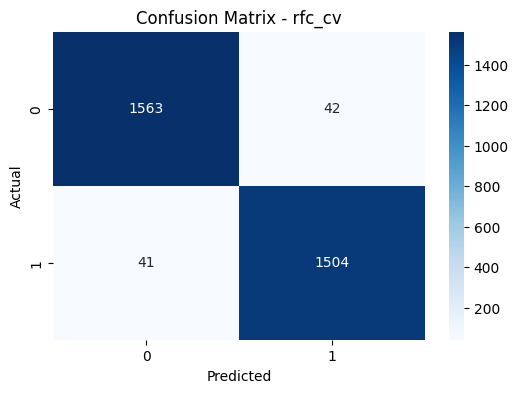

In [81]:
accuracy = accuracy_score(y_test, pred_rfc_cv) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_cv))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_cv,name_model="rfc_cv", save=True)

### TfidfVectorizer 

0.9733333333333334
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



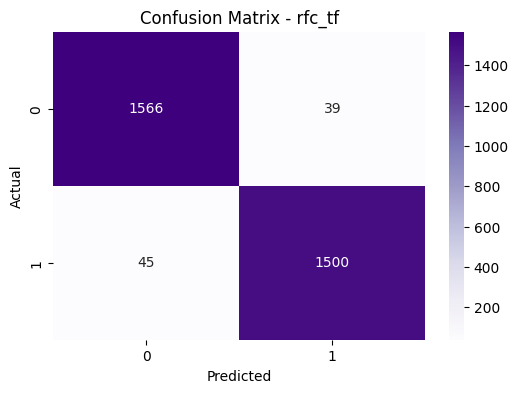

In [82]:
accuracy = accuracy_score(y_test, pred_rfc_tf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_tf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_tf,name_model="rfc_tf", save=True)

### Word2Vec

0.966031746031746
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1605
           1       0.97      0.96      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



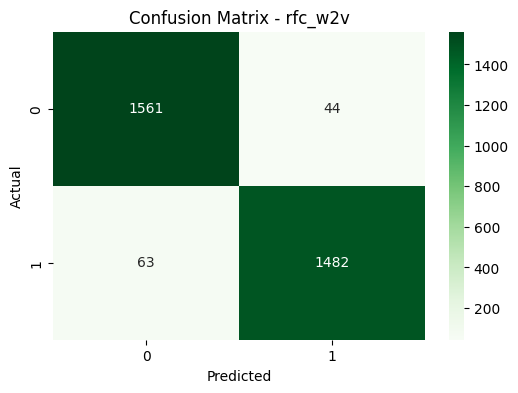

In [83]:
accuracy = accuracy_score(y_test, pred_rfc_w2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_w2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_w2v,name_model="rfc_w2v", save=True)


## Doc2Vec

0.9450793650793651
-------------------

              precision    recall  f1-score   support

           0       0.96      0.93      0.95      1605
           1       0.93      0.96      0.94      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



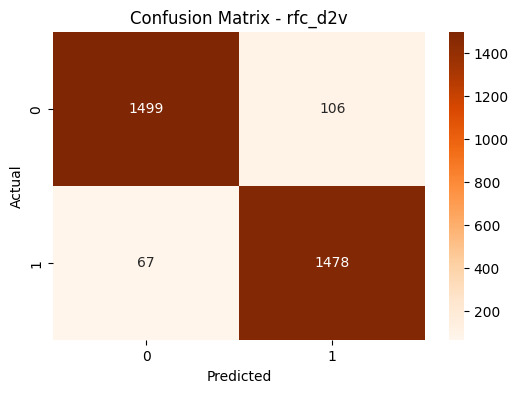

In [84]:
accuracy = accuracy_score(y_test, pred_rfc_d2v) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=pred_rfc_d2v))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=pred_rfc_d2v,name_model="rfc_d2v", save=True)

*Save model RFC*

In [85]:
# joblib.dump(rfc_cv, model_RFC_CV)
# joblib.dump(rfc_tf, model_RFC_TF)
# joblib.dump(vectorizerW2V,model_vector_W2V)
# joblib.dump(rfc_d2v, model_RFC_D2V)

# Bước 2:Vector hóa TF-IDF

## Navie bayes

In [86]:
nb_model = MultinomialNB()
nb_model.fit(Xv_trainTF, y_train)
y_pred_nb = nb_model.predict(Xv_testTF)

0.9546031746031746
-------------------

              precision    recall  f1-score   support

           0       0.96      0.95      0.96      1605
           1       0.95      0.96      0.95      1545

    accuracy                           0.95      3150
   macro avg       0.95      0.95      0.95      3150
weighted avg       0.95      0.95      0.95      3150

-------------------



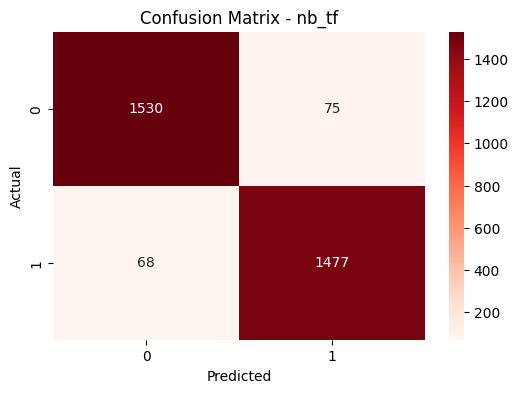

In [87]:
accuracy = accuracy_score(y_test, y_pred_nb) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_nb))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_nb,name_model="nb_tf")

## DecisionTree

In [88]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(Xv_trainTF, y_train)
y_pred_dt = dt_model.predict(Xv_testTF)

0.9149206349206349
-------------------

              precision    recall  f1-score   support

           0       0.92      0.91      0.92      1605
           1       0.91      0.92      0.91      1545

    accuracy                           0.91      3150
   macro avg       0.91      0.92      0.91      3150
weighted avg       0.92      0.91      0.91      3150

-------------------



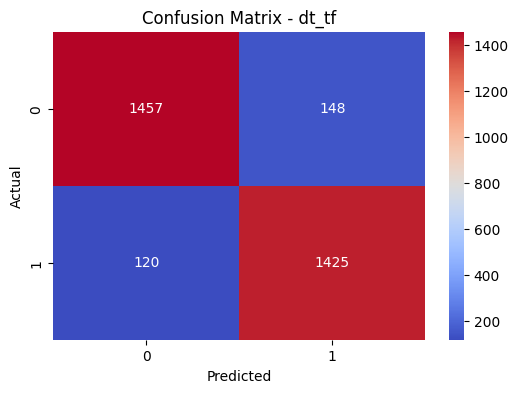

In [89]:
accuracy = accuracy_score(y_test, y_pred_dt) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_dt))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_dt,name_model="dt_tf")

## RandomForest

In [90]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(Xv_trainTF, y_train)
y_pred_rf = rf_model.predict(Xv_testTF)

0.9733333333333334
-------------------

              precision    recall  f1-score   support

           0       0.97      0.98      0.97      1605
           1       0.97      0.97      0.97      1545

    accuracy                           0.97      3150
   macro avg       0.97      0.97      0.97      3150
weighted avg       0.97      0.97      0.97      3150

-------------------



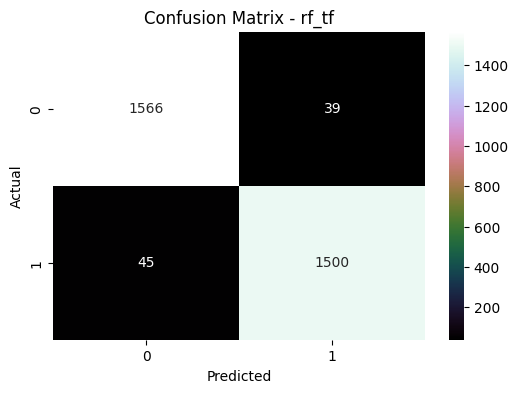

In [91]:
accuracy = accuracy_score(y_test, y_pred_rf) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_rf))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_rf,name_model="rf_tf")

## SVM

In [92]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(Xv_trainTF, y_train)
y_pred_svm = svm_model.predict(Xv_testTF)

0.9834920634920635
-------------------

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1605
           1       0.99      0.98      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



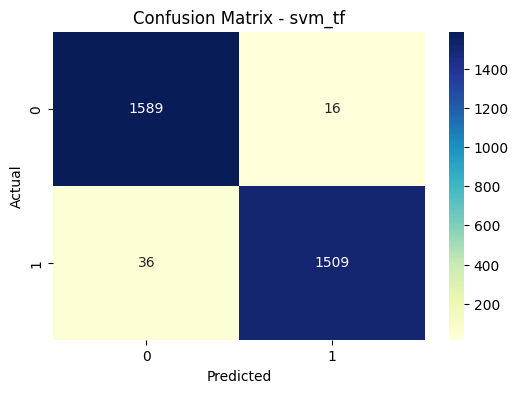

In [93]:
accuracy = accuracy_score(y_test, y_pred_svm) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_svm))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_svm,name_model="svm_tf")

## LogisticRegression

In [94]:
lr_model = LogisticRegression()
lr_model.fit(Xv_trainTF, y_train)
y_pred_lr = lr_model.predict(Xv_testTF)

0.9758730158730159
-------------------

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1605
           1       0.98      0.97      0.98      1545

    accuracy                           0.98      3150
   macro avg       0.98      0.98      0.98      3150
weighted avg       0.98      0.98      0.98      3150

-------------------



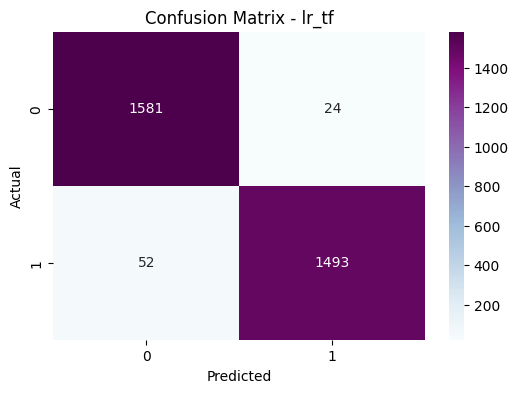

In [95]:
accuracy = accuracy_score(y_test, y_pred_lr) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_lr))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_lr,name_model="lr_tf")

## GradientBoostingClassifier

In [96]:
gbc_model = GradientBoostingClassifier(random_state=0)
gbc_model.fit(Xv_trainTF, y_train)
y_pred_gbc = gbc_model.predict(Xv_testTF)

0.9603174603174603
-------------------

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1605
           1       0.97      0.95      0.96      1545

    accuracy                           0.96      3150
   macro avg       0.96      0.96      0.96      3150
weighted avg       0.96      0.96      0.96      3150

-------------------



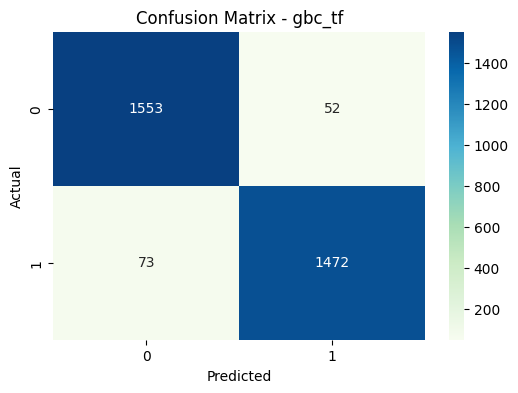

In [97]:
accuracy = accuracy_score(y_test, y_pred_gbc) 
print(accuracy)
print('-------------------\n')

print(classification_report(y_true=y_test, y_pred=y_pred_gbc))
print('-------------------\n')

evaluate_model(y_true=y_test, y_pred=y_pred_gbc,name_model="gbc_tf")

**save**

In [98]:
model_SVM_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_SVM_model_TF.joblib")
joblib.dump(svm_model, model_SVM_TF)

['../../Vector/Vietnamese\\Vietnamese_SVM_model_TF.joblib']

In [99]:
model_RFC_TF = os.path.join("../../Vector/Vietnamese", "Vietnamese_RFC_model_TF.joblib")
joblib.dump(rf_model, model_RFC_TF)

['../../Vector/Vietnamese\\Vietnamese_RFC_model_TF.joblib']